In [1]:
import cv2
import matplotlib.pyplot as plt

In [2]:
def add_text_bottom_right(text, img, fontFace=cv2.FONT_HERSHEY_SIMPLEX, fontScale=1.0, color=(0, 255, 0), thickness=2, margin=20):
    image_with_text = img.copy()

    # Get text size
    text_size, _ = cv2.getTextSize(text, fontFace, fontScale, thickness)
    text_width, text_height = text_size

    org_x = image_with_text.shape[1] - text_width - margin
    org_y = image_with_text.shape[0] - margin


    if org_x < 0: org_x = 0
    if org_y < text_height: org_y = text_height
    cv2.putText(image_with_text, text, (org_x, org_y), fontFace, fontScale, color, thickness, cv2.LINE_AA)
    return image_with_text

# Exercise 2

In [3]:
# Install necessary libraries
!apt-get update
!apt-get install -y libzbar0
!pip install pyzbar

'apt-get' is not recognized as an internal or external command,
operable program or batch file.
'apt-get' is not recognized as an internal or external command,
operable program or batch file.


     -------------------------------------- 817.4/817.4 KB 2.9 MB/s eta 0:00:00


You should consider upgrading via the 'C:\Users\ADMIN\.pyenv\pyenv-win\versions\3.10.3\python.exe -m pip install --upgrade pip' command.


In [6]:
from pyzbar import pyzbar

img = cv2.imread('input_ex02.jpg')
# Kiểm tra xem ảnh đã được tải thành công chưa
if img is None:
    print("Lỗi: Không thể tải ảnh. Vui lòng kiểm tra đường dẫn hoặc tệp ảnh.")
    exit()

# Danh sách các góc xoay để thử (0, 90, 180, 270 độ)
rotations = [
    None,  # Thử ảnh gốc trước
    cv2.ROTATE_90_CLOCKWISE,
    cv2.ROTATE_180,
    cv2.ROTATE_90_COUNTERCLOCKWISE
]

barcodes = []
img_to_scan = img.copy()

for rotation in rotations:
    if rotation is not None:
        # Xoay ảnh
        img_to_scan = cv2.rotate(img, rotation)

    # Giải mã ảnh (đã xoay hoặc gốc)
    barcodes = pyzbar.decode(img_to_scan)

    # Nếu tìm thấy barcode, dừng vòng lặp
    if barcodes:
        print(f"Tìm thấy barcode ở góc xoay: {rotation}")
        break

# In kết quả
if barcodes:
    for barcode in barcodes:
        # Lấy thông tin
        barcode_data = barcode.data.decode('utf-8')
        barcode_type = barcode.type

        # Lấy vị trí (bounding box)
        (x, y, w, h) = barcode.rect
        print(f"Loại: {barcode_type}, Dữ liệu: {barcode_data}")
        print(f"Vị trí (rect): x={x}, y={y}, w={w}, h={h}")

else:
    print("Không tìm thấy barcode ở bất kỳ góc xoay nào.")

Tìm thấy barcode ở góc xoay: None
Loại: EAN13, Dữ liệu: 9787118081473
Vị trí (rect): x=48, y=520, w=92, h=141
Loại: EAN13, Dữ liệu: 9787122276124
Vị trí (rect): x=420, y=518, w=141, h=92
Loại: EAN13, Dữ liệu: 9783319200064
Vị trí (rect): x=378, y=192, w=182, h=63
Loại: EAN13, Dữ liệu: 9787564350840
Vị trí (rect): x=17, y=172, w=140, h=82


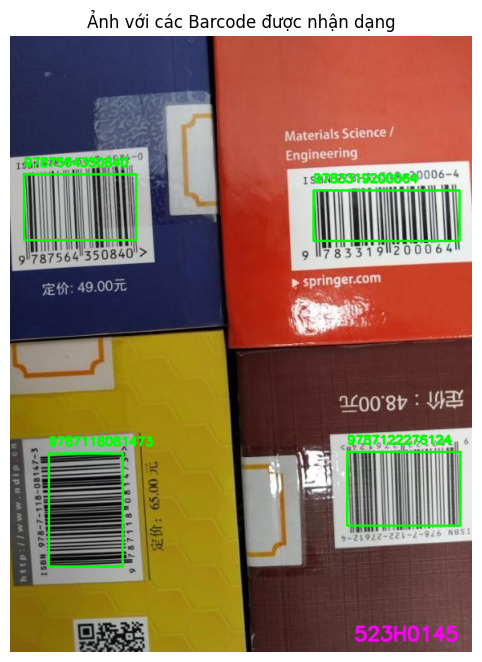

In [5]:

img_with_boxes = img.copy()
if barcodes:
    for barcode in barcodes:
        (x, y, w, h) = barcode.rect

        # Vẽ hình chữ nhật lên ảnh
        cv2.rectangle(img_with_boxes, (x, y), (x + w, y + h), (0, 255, 0), 2)

        barcode_data = barcode.data.decode('utf-8')
        cv2.putText(img_with_boxes, barcode_data, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    text_to_add = "523H0145"
    img_with_boxes = add_text_bottom_right(text_to_add, img_with_boxes, color=(255, 0, 255), fontScale=0.8, thickness=2, margin=15)

    img_rgb = cv2.cvtColor(img_with_boxes, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 8))
    plt.imshow(img_rgb)
    plt.title("Ảnh với các Barcode được nhận dạng")
    plt.axis('off') # Tắt trục tọa độ
    plt.show()
else:
    print("Không tìm thấy barcode nào để vẽ.")